In [1]:
import math
import os
import random
import sys

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm import tqdm

In [3]:
torch.__version__

'2.12.0+cpu'

# 1. Простейшие операции на pytorch
В этой части вам надо будет реализовать несколько функций активации. Вы можете пока не знать, какие у них есть свойства и чем они хороши. Разговор об этом пойдёт на будущих лекциях. Достаточно просто познакомиться с ними, вбив формулы.

**[0.25 балла]** Cоздайте два случайных тензора (двумерных, не квадратных). Умножьте их друг на друга, результат запишите в третий тензор.

In [8]:
x = torch.tensor([
    [1.0, 2.0, 3.4],
    [3.0, 2.3, 3.2]
                 ])
y = torch.tensor([
    [1.3, 2.54, 3.445],
    [3.4, 2.2, 1.75]
                 ])
res = x.T @ y
res

tensor([[11.5000,  9.1400,  8.6950],
        [10.4200, 10.1400, 10.9150],
        [15.3000, 15.6760, 17.3130]])

**[0.25 балла]** Реализуйте ReLU используя только pytorch, примените его к тензору x (запрещено использование модулей torch.nn и его подмодулей, а также torch.relu

In [15]:
def relu_forward(x):
    return torch.maximum(torch.tensor(0), x)

assert torch.all(F.relu(x) == relu_forward(x))

**[0.25 балла]** Сделайте тоже самое c ELU, Exponential Linear Units

In [24]:
def elu_forward(x):
    # your code here (ง •̀_•́)ง
    return torch.where(x > 0, x, torch.exp(x) - 1)

assert torch.allclose(F.elu(x), elu_forward(x), 1e-4)

**[0.25 балла]** Сделайте тоже самое c LeakyReLU, Leaky Rectified Linear Unit

In [31]:
def lrelu_forward(x, alpha):
    return torch.maximum(x * alpha, x)
assert torch.all(F.leaky_relu(x, 0.01) == lrelu_forward(x, 0.01))

**[0.25 балла]** Теперь перейдем к немного более современным функциям активаций, например Mish, она выглядит следующим образом:

In [48]:
def mish(inputs):
    return inputs * torch.tanh(torch.log(1 + torch.exp(inputs)))

In [50]:
assert torch.allclose(
    mish(torch.tensor([1, 1, 1], dtype=torch.float32)),
    torch.tensor([0.8651, 0.8651, 0.8651]),
    atol=1e-4,
)

In [52]:
assert torch.allclose(
    mish(torch.tensor([0.6376, 0.4021, 0.6656, 0.3726], dtype=torch.float64)),
    torch.tensor([0.5014, 0.2908, 0.5280, 0.2663], dtype=torch.float64),
    atol=1e-4,
)

**[0.25 балла]** Теперь реализуем swish, она выглядит следующим образом:



In [63]:
def swish(x):
    sigm = 1 / (1 + torch.exp(-x))
    return x * sigm

In [65]:
assert torch.allclose(
    swish(torch.tensor([1, 1, 1], dtype=torch.float32)),
    torch.tensor([0.7311, 0.7311, 0.7311]),
    atol=1e-4,
)

In [67]:
assert torch.allclose(
    swish(torch.tensor([0.6376, 0.4021, 0.6656, 0.3726], dtype=torch.float64)),
    torch.tensor([0.4171, 0.2409, 0.4396, 0.2206], dtype=torch.float64),
    atol=1e-4,
)

**[0.5]** Напишите на pytorch код, который решит следующую задачу оптимизации с помощью градиентного спуска:
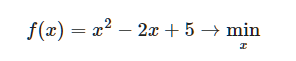

In [77]:
def op_f(x, lr, num_ep):
    x = torch.tensor(x, requires_grad=True)
    for _ in range(num_ep):
        f = x ** 2 - 2 * x + 5
        f.backward()
        with torch.no_grad():
            x -= lr * x.grad
        x.grad.zero_()
    return x

# 2. Логистическая регрессия

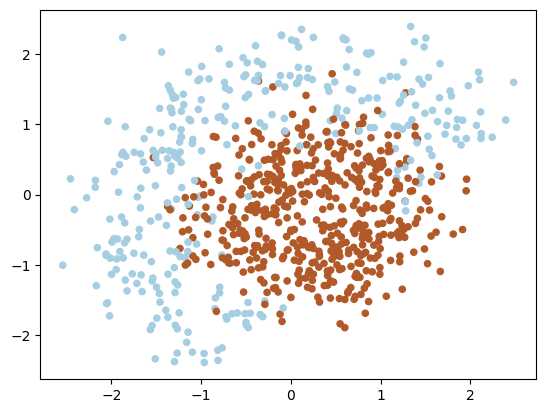

In [80]:
from sklearn import datasets, preprocessing

(X, y) = datasets.make_circles(n_samples=1024, shuffle=True, 
                               noise=0.2, factor=0.4, random_state=42)

ind = np.logical_or(y == 1, X[:, 1] > X[:, 0] - 0.5)
X = X[ind, :]
m = np.array([[1, 1], [-2, 1]])
X = preprocessing.scale(X)
y = y[ind]

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Paired, s=20)
plt.show()

In [82]:
X = torch.from_numpy(X)
y = torch.from_numpy(y)